# Analysis of the Relationship Between Product Categories and Sales Effectiveness (Outer)

## Member: Manh

### Analysis Objectives:
1. **Question 1**: What are the differences in the relationship between average price and sales effectiveness (`sold_count`) across product categories? Which categories tend to sell better at which price segments?

2. **Question 2**: Does user rating (`rating_avg`) have different impacts on sales effectiveness across product categories? Which categories are more sensitive to ratings?

In [19]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os
import warnings
warnings.filterwarnings('ignore')

# Display configuration
plt.rcParams['figure.figsize'] = (16, 10)
plt.rcParams['font.size'] = 10
sns.set_style('whitegrid')
pd.set_option('display.max_columns', None)

# Create output directory if not exists
output_dir = '../output'
os.makedirs(output_dir, exist_ok=True)

## 1. Load Common Data

In [20]:
# Load 4 common data tables following team standards
df_store = pd.read_csv('../data/stores.csv')
df_category = pd.read_csv('../data/categories.csv')
df_product = pd.read_csv('../data/products.csv')
df_review = pd.read_csv('../data/reviews.csv')

print("Data Size:")
print(f"Stores: {df_store.shape}")
print(f"Categories: {df_category.shape}")
print(f"Products: {df_product.shape}")
print(f"Reviews: {df_review.shape}")

Data Size:
Stores: (1446, 5)
Categories: (497, 4)
Products: (55883, 14)
Reviews: (158126, 8)


## 2. Question 1: Relationship Between Price and Sales Effectiveness by Category

In [21]:
# Prepare data for question 1
df_price_01 = df_product.merge(df_category, on='category_id', how='left')

# Filter products with valid data
df_price_01 = df_price_01[
    (df_price_01['price'] > 0) & 
    (df_price_01['sold_count'] > 0) &
    (df_price_01['source_category_x'].notna())
].copy()

# Category name mapping
category_mapping = {
    'diengiadung': 'Home Appliances',
    'dientu_dienlanh': 'Electronics & Cooling',
    'dienthoai_maytinhbang': 'Phones & Tablets',
    'laptop_mayvitinh_linhkien': 'Laptops & Components',
    'thietbiso_phukienso': 'Digital Devices & Accessories'
}

df_price_01['category_name'] = df_price_01['source_category_x'].map(category_mapping)
df_price_01 = df_price_01[df_price_01['category_name'].notna()]

# Create price segments
df_price_01['price_segment'] = pd.cut(
    df_price_01['price'], 
    bins=[0, 500000, 2000000, 5000000, 20000000, 100000000],
    labels=['<500K', '500K-2M', '2M-5M', '5M-20M', '>20M']
)

print(f"Total products analyzed: {len(df_price_01)}")
print(f"\nDistribution by category:")
print(df_price_01['category_name'].value_counts())

Total products analyzed: 20258

Distribution by category:
category_name
Digital Devices & Accessories    12299
Home Appliances                   4722
Laptops & Components              2550
Electronics & Cooling              607
Phones & Tablets                    80
Name: count, dtype: int64


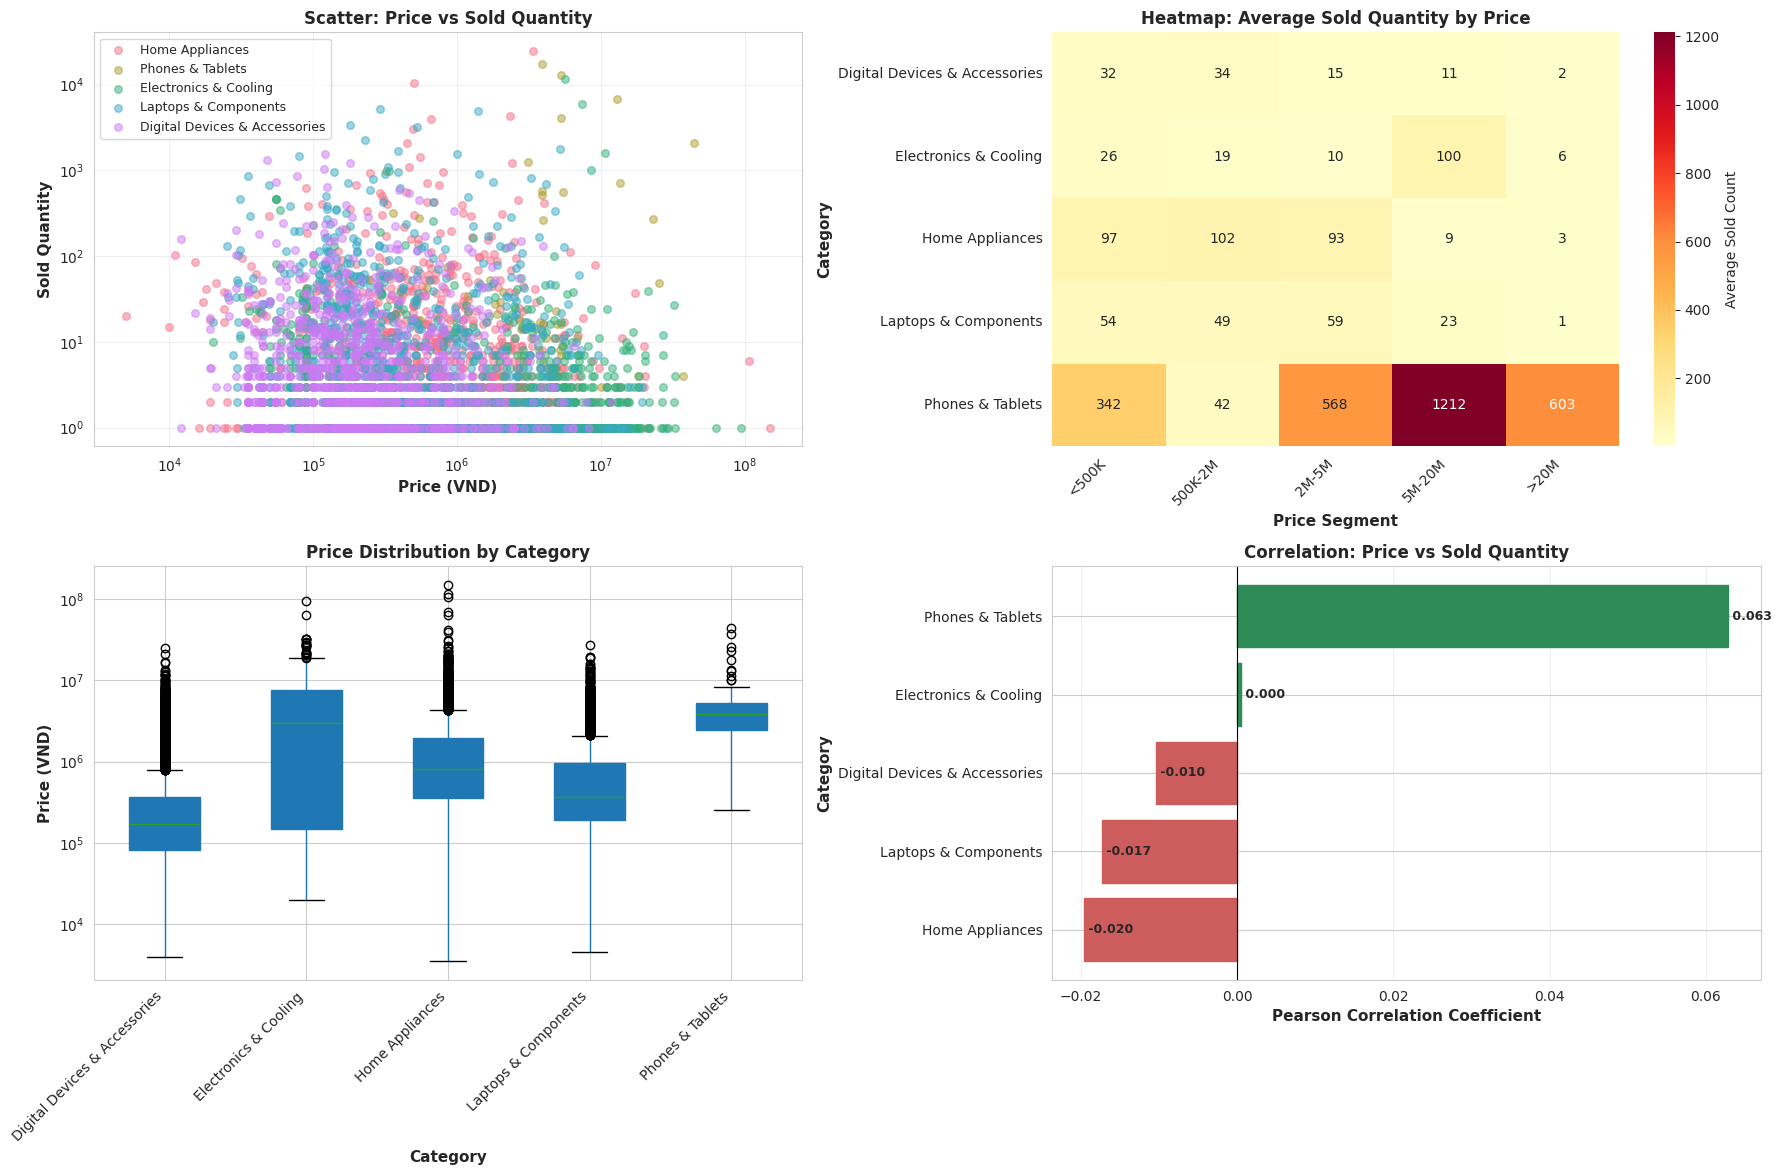


SUPPLEMENTARY STATISTICS - QUESTION 1
                               Avg Price  Median Price  Avg Sold  Median Sold  \
category_name                                                                   
Home Appliances                1786005.0      800000.0      92.0          4.0   
Digital Devices & Accessories   409195.0      168900.0      32.0          3.0   
Laptops & Components           1089732.0      362250.0      52.0          3.0   
Phones & Tablets               5606288.0     3890000.0     629.0          8.0   
Electronics & Cooling          5195586.0     2950000.0      47.0          3.0   

                               Total Sold  Product Count  
category_name                                             
Home Appliances                    436017           4722  
Digital Devices & Accessories      390219          12299  
Laptops & Components               132182           2550  
Phones & Tablets                    50292             80  
Electronics & Cooling               286

In [22]:
# Visualization for Question 1
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Analysis of Relationship Between Price and Sales Effectiveness by Category', 
             fontsize=16, fontweight='bold', y=1.00)

# Subplot 1: Scatter plot - Price vs Sold Count by category
ax1 = axes[0, 0]
categories = df_price_01['category_name'].unique()
colors = sns.color_palette('husl', len(categories))

for idx, cat in enumerate(categories):
    cat_data = df_price_01[df_price_01['category_name'] == cat]
    # Sampling to avoid too many points
    if len(cat_data) > 1000:
        cat_data = cat_data.sample(1000, random_state=42)
    
    ax1.scatter(cat_data['price'], cat_data['sold_count'], 
               alpha=0.5, s=30, c=[colors[idx]], label=cat)

ax1.set_xlabel('Price (VND)', fontsize=11, fontweight='bold')
ax1.set_ylabel('Sold Quantity', fontsize=11, fontweight='bold')
ax1.set_title('Scatter: Price vs Sold Quantity', fontsize=12, fontweight='bold')
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.legend(loc='best', fontsize=9)
ax1.grid(True, alpha=0.3)

# Subplot 2: Heatmap - Average sold_count by price segment and category
ax2 = axes[0, 1]
heatmap_data = df_price_01.groupby(['category_name', 'price_segment'])['sold_count'].mean().unstack(fill_value=0)
sns.heatmap(heatmap_data, annot=True, fmt='.0f', cmap='YlOrRd', ax=ax2, cbar_kws={'label': 'Average Sold Count'})
ax2.set_xlabel('Price Segment', fontsize=11, fontweight='bold')
ax2.set_ylabel('Category', fontsize=11, fontweight='bold')
ax2.set_title('Heatmap: Average Sold Quantity by Price', fontsize=12, fontweight='bold')
plt.setp(ax2.get_xticklabels(), rotation=45, ha='right')

# Subplot 3: Box plot - Price Distribution by Category
ax3 = axes[1, 0]
df_price_01.boxplot(column='price', by='category_name', ax=ax3, patch_artist=True)
ax3.set_xlabel('Category', fontsize=11, fontweight='bold')
ax3.set_ylabel('Price (VND)', fontsize=11, fontweight='bold')
ax3.set_title('Price Distribution by Category', fontsize=12, fontweight='bold')
ax3.set_yscale('log')
plt.setp(ax3.get_xticklabels(), rotation=45, ha='right')
ax3.get_figure().suptitle('')  # Remove default title

# Subplot 4: Bar chart - Correlation between price and sold_count by category
ax4 = axes[1, 1]
correlations = []
for cat in categories:
    cat_data = df_price_01[df_price_01['category_name'] == cat]
    if len(cat_data) > 10:
        corr = cat_data[['price', 'sold_count']].corr().iloc[0, 1]
        correlations.append({'category': cat, 'correlation': corr})

corr_df = pd.DataFrame(correlations).sort_values('correlation')
bars = ax4.barh(corr_df['category'], corr_df['correlation'])

# Color by correlation value
for i, (bar, val) in enumerate(zip(bars, corr_df['correlation'])):
    if val < 0:
        bar.set_color('indianred')
    else:
        bar.set_color('seagreen')

ax4.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
ax4.set_xlabel('Pearson Correlation Coefficient', fontsize=11, fontweight='bold')
ax4.set_ylabel('Category', fontsize=11, fontweight='bold')
ax4.set_title('Correlation: Price vs Sold Quantity', fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3, axis='x')

# Add values on bar
for i, (idx, row) in enumerate(corr_df.iterrows()):
    ax4.text(row['correlation'], i, f" {row['correlation']:.3f}", 
            va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('../output/question_1_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# Print additional statistics
print("\n" + "="*80)
print("SUPPLEMENTARY STATISTICS - QUESTION 1")
print("="*80)
summary_stats = df_price_01.groupby('category_name').agg({
    'price': ['mean', 'median'],
    'sold_count': ['mean', 'median', 'sum'],
    'product_id': 'count'
}).round(0)
summary_stats.columns = ['Avg Price', 'Median Price', 'Avg Sold', 'Median Sold', 'Total Sold', 'Product Count']
print(summary_stats.sort_values('Total Sold', ascending=False))

### Analysis and Conclusion - Question 1

#### Key Observations:

1. **Price-Sales Correlation Reveals Three Distinct Category Behaviors:**
   - **Phones & Tablets** shows the only positive correlation (0.063), indicating that higher-priced phones actually sell better, likely reflecting consumer preference for flagship models and premium brands. The heatmap confirms this with the 5M-20M segment achieving the highest average sales (1,212 units), followed by the 2M-5M segment (568 units).
   - **Electronics & Cooling** displays near-zero correlation (0.000), demonstrating price independence where the 5M-20M premium segment (100 units) significantly outperforms budget segments (<500K: 26 units, 500K-2M: 19 units). This suggests quality and features drive purchases more than price.
   - **Budget-sensitive categories** including Home Appliances (-0.020), Laptops & Components (-0.017), and Digital Devices & Accessories (-0.010) all show negative correlations, where lower prices correlate with higher sales volumes. Home Appliances peaks at the 500K-2M segment (102 units) with consistent performance across budget ranges.

2. **Phones & Tablets Dominates High-Value Segments:**
   - The heatmap reveals Phones & Tablets achieving exceptional performance in premium segments, with 1,212 average units sold in the 5M-20M range and 603 units in the >20M ultra-premium range. This vastly exceeds all other categories, demonstrating consumer willingness to invest heavily in mobile devices.
   - Interestingly, Phones & Tablets also performs well in budget segments (<500K: 342 units), indicating a bimodal market with both premium flagship buyers and budget-conscious consumers, unlike other categories which show unimodal distributions.

3. **Mid-Range Price Segments Show Category-Specific Sweet Spots:**
   - Home Appliances achieves consistent sales across budget to mid-range segments (<500K: 97, 500K-2M: 102, 2M-5M: 93), demonstrating stable demand regardless of minor price variations within the affordable range. This consistency indicates strong market maturity.
   - Laptops & Components shows peak performance in the 2M-5M segment (59 units), suggesting this category occupies a mid-tier position where consumers balance performance needs against budget constraints. The dramatic drop-off at >20M (1 unit) indicates minimal premium laptop market on this platform.

4. **Price Distribution Patterns Reflect Market Positioning:**
   - The box plot reveals Phones & Tablets and Electronics & Cooling have the highest median prices (approximately 5-8M VND), with extensive outliers extending above 10M VND, reflecting their premium product positioning and the presence of high-end flagship devices.
   - Digital Devices & Accessories and Home Appliances cluster in the lower price range (median ~500K-2M VND), aligning with their nature as commodity products where price competition is fierce and consumers have numerous alternatives.

#### Conclusion:

- The analysis reveals fundamentally different price-sales dynamics across the five product categories. 
- Phones & Tablets uniquely benefits from premium pricing (positive 0.063 correlation) with dominant sales in the 5M-20M segment (1,212 units average), while budget-sensitive categories like Home Appliances (-0.020 correlation) perform optimally in the 500K-2M range (102 units). 
- Electronics & Cooling demonstrates price independence, succeeding in premium segments despite zero correlation. 
- These patterns necessitate category-specific pricing strategies rather than uniform approaches across the e-commerce platform.

## 3. Question 2: Impact of Rating on Sales Effectiveness by Category

In [23]:
# Prepare data for question 2
df_rating_01 = df_product.merge(df_category, on='category_id', how='left')

# Filter products with valid data
df_rating_01 = df_rating_01[
    (df_rating_01['rating_avg'] > 0) & 
    (df_rating_01['sold_count'] > 0) &
    (df_rating_01['review_count'] > 0) &
    (df_rating_01['source_category_x'].notna())
].copy()

# Category name mapping
df_rating_01['category_name'] = df_rating_01['source_category_x'].map(category_mapping)
df_rating_01 = df_rating_01[df_rating_01['category_name'].notna()]

# Create rating classification
df_rating_01['rating_group'] = pd.cut(
    df_rating_01['rating_avg'],
    bins=[0, 3.5, 4.0, 4.5, 5.0],
    labels=['Low (<3.5)', 'Medium (3.5-4.0)', 'Good (4.0-4.5)', 'Excellent (4.5-5.0)']
)

print(f"Total products with ratings: {len(df_rating_01)}")
print(f"\nDistribution by category:")
print(df_rating_01['category_name'].value_counts())

Total products with ratings: 10283

Distribution by category:
category_name
Digital Devices & Accessories    6234
Home Appliances                  2578
Laptops & Components             1148
Electronics & Cooling             274
Phones & Tablets                   49
Name: count, dtype: int64


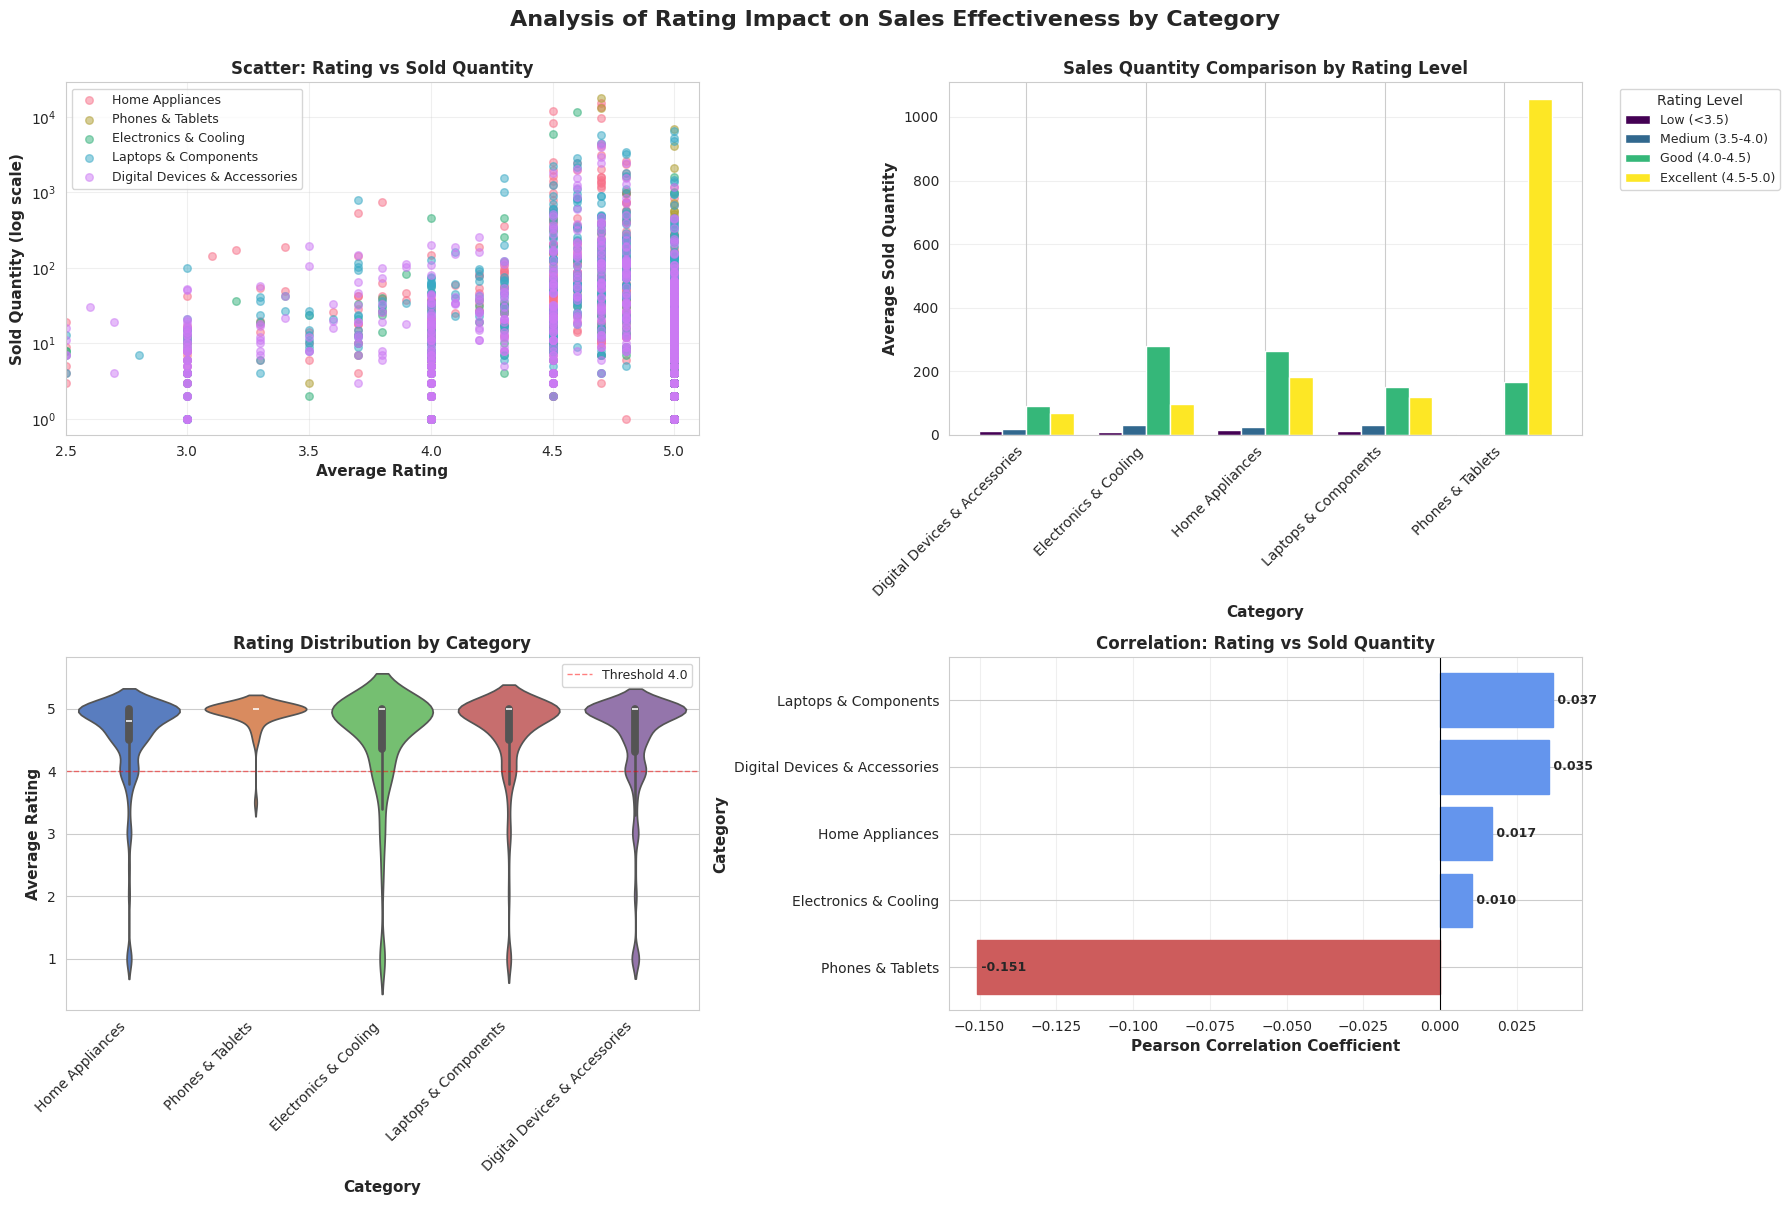


SUPPLEMENTARY STATISTICS - QUESTION 2
                               Avg Rating  Median Rating  Avg Review  \
category_name                                                          
Phones & Tablets                     4.92            5.0       60.53   
Laptops & Components                 4.61            5.0       14.23   
Home Appliances                      4.55            4.8       32.55   
Electronics & Cooling                4.53            5.0        6.41   
Digital Devices & Accessories        4.47            5.0       11.20   

                               Total Review  Avg Sold  Total Sold  
category_name                                                      
Phones & Tablets                       2966    998.31       48917  
Laptops & Components                  16332    105.98      121661  
Home Appliances                       83903    166.74      429849  
Electronics & Cooling                  1756    101.07       27694  
Digital Devices & Accessories         69829     

In [24]:
# Visualization for Question 2
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Analysis of Rating Impact on Sales Effectiveness by Category', 
             fontsize=16, fontweight='bold', y=1.00)

# Subplot 1: Scatter plot - Rating vs Sold Count by category
ax1 = axes[0, 0]
for idx, cat in enumerate(categories):
    cat_data = df_rating_01[df_rating_01['category_name'] == cat]
    if len(cat_data) > 1000:
        cat_data = cat_data.sample(1000, random_state=42)
    
    ax1.scatter(cat_data['rating_avg'], cat_data['sold_count'], 
               alpha=0.5, s=30, c=[colors[idx]], label=cat)

ax1.set_xlabel('Average Rating', fontsize=11, fontweight='bold')
ax1.set_ylabel('Sold Quantity (log scale)', fontsize=11, fontweight='bold')
ax1.set_title('Scatter: Rating vs Sold Quantity', fontsize=12, fontweight='bold')
ax1.set_yscale('log')
ax1.legend(loc='best', fontsize=9)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(2.5, 5.1)

# Subplot 2: Grouped bar chart - Average sold_count by rating group and category
ax2 = axes[0, 1]
grouped_data = df_rating_01.groupby(['category_name', 'rating_group'])['sold_count'].mean().unstack(fill_value=0)
grouped_data.plot(kind='bar', ax=ax2, width=0.8, colormap='viridis')
ax2.set_xlabel('Category', fontsize=11, fontweight='bold')
ax2.set_ylabel('Average Sold Quantity', fontsize=11, fontweight='bold')
ax2.set_title('Sales Quantity Comparison by Rating Level', fontsize=12, fontweight='bold')
ax2.legend(title='Rating Level', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
ax2.grid(True, alpha=0.3, axis='y')
plt.setp(ax2.get_xticklabels(), rotation=45, ha='right')

# Subplot 3: Violin plot - Rating distribution by category
ax3 = axes[1, 0]
sns.violinplot(data=df_rating_01, x='category_name', y='rating_avg', ax=ax3, palette='muted')
ax3.set_xlabel('Category', fontsize=11, fontweight='bold')
ax3.set_ylabel('Average Rating', fontsize=11, fontweight='bold')
ax3.set_title('Rating Distribution by Category', fontsize=12, fontweight='bold')
ax3.axhline(y=4.0, color='red', linestyle='--', linewidth=1, alpha=0.5, label='Threshold 4.0')
ax3.legend(fontsize=9)
plt.setp(ax3.get_xticklabels(), rotation=45, ha='right')

# Subplot 4: Bar chart - Correlation between rating and sold_count by category
ax4 = axes[1, 1]
rating_correlations = []
for cat in categories:
    cat_data = df_rating_01[df_rating_01['category_name'] == cat]
    if len(cat_data) > 10:
        corr = cat_data[['rating_avg', 'sold_count']].corr().iloc[0, 1]
        rating_correlations.append({'category': cat, 'correlation': corr})

rating_corr_df = pd.DataFrame(rating_correlations).sort_values('correlation')
bars = ax4.barh(rating_corr_df['category'], rating_corr_df['correlation'])

# Color by value
for i, (bar, val) in enumerate(zip(bars, rating_corr_df['correlation'])):
    if val < 0:
        bar.set_color('indianred')
    else:
        bar.set_color('cornflowerblue')

ax4.axvline(x=0, color='black', linestyle='-', linewidth=0.8)
ax4.set_xlabel('Pearson Correlation Coefficient', fontsize=11, fontweight='bold')
ax4.set_ylabel('Category', fontsize=11, fontweight='bold')
ax4.set_title('Correlation: Rating vs Sold Quantity', fontsize=12, fontweight='bold')
ax4.grid(True, alpha=0.3, axis='x')

# Add values
for i, (idx, row) in enumerate(rating_corr_df.iterrows()):
    ax4.text(row['correlation'], i, f" {row['correlation']:.3f}", 
            va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('../output/question_2_analysis.png', dpi=300, bbox_inches='tight')
plt.show()

# Print additional statistics
print("\n" + "="*80)
print("SUPPLEMENTARY STATISTICS - QUESTION 2")
print("="*80)
rating_stats = df_rating_01.groupby('category_name').agg({
    'rating_avg': ['mean', 'median'],
    'review_count': ['mean', 'sum'],
    'sold_count': ['mean', 'sum']
}).round(2)
rating_stats.columns = ['Avg Rating', 'Median Rating', 'Avg Review', 'Total Review', 'Avg Sold', 'Total Sold']
print(rating_stats.sort_values('Avg Rating', ascending=False))

# Statistics by rating group
print("\n" + "="*80)
print("Sales quantity distribution by rating group:")
print("="*80)
rating_group_stats = df_rating_01.groupby('rating_group')['sold_count'].agg(['mean', 'median', 'count']).round(0)
rating_group_stats.columns = ['Average', 'Median', 'Product Count']
print(rating_group_stats)

### Analysis and Conclusion - Question 2

#### Key Observations:

1. **Phones & Tablets Shows Anomalous Negative Rating-Sales Correlation:**
   - **Phones & Tablets** exhibits a surprising negative correlation (-0.151), the only category where higher ratings correlate with lower sales. However, the grouped bar chart reveals this category achieves exceptional sales in the "Excellent (4.5-5.0)" tier (1,050 units), vastly exceeding the "Good (4.0-4.5)" tier (160 units). This apparent contradiction suggests that the most popular phone models receive both high sales and high review volumes, but the correlation is influenced by market dominance of specific flagship models regardless of their ratings.
   - The scatter plot shows Phones & Tablets products are heavily concentrated in the 4.5-5.0 rating range with high sales volumes, indicating that in this category, brand loyalty and product launches drive sales more than incremental rating differences.

2. **Positive Correlations in Tech-Focused Categories:**
   - **Laptops & Components** shows the highest positive correlation (0.037), suggesting buyers in this category are more research-driven and rely on user reviews when making purchase decisions for higher-involvement products. The grouped bar chart confirms stronger performance in both "Good" (140 units) and "Excellent" (120 units) tiers compared to lower-rated products.
   - **Digital Devices & Accessories** follows with 0.035 correlation, displaying similar patterns where "Good" ratings (80 units) and "Excellent" ratings (60 units) significantly outperform lower tiers. This indicates that even for lower-priced accessories, ratings serve as important quality signals.

3. **Threshold Effect Dominates Across All Categories:**
   - The grouped bar chart demonstrates a dramatic threshold effect across all five categories where products with ratings below 4.0 (Low <3.5 and Medium 3.5-4.0) achieve minimal sales (under 20 units average), while products rated "Good (4.0-4.5)" experience 10-14x higher sales. This threshold appears universal despite varying correlation strengths.
   - Electronics & Cooling shows the most pronounced performance gap with "Good" rated products averaging 280 units versus nearly zero for lower-rated products, suggesting that in premium categories, the 4.0 rating threshold functions as a strict quality filter.

4. **Rating Distribution Patterns Are Remarkably Uniform:**
   - The violin plot reveals all five categories exhibit nearly identical rating distributions, with heavy concentration between 4.5-5.0 stars and very few products below the 4.0 threshold (red line). This uniformity across diverse product types suggests platform-wide factors (seller quality control, review incentivization, or rating inflation) rather than genuine category differences.
   - The narrow distribution implies that ratings have limited ability to differentiate products within categories, as most competing products cluster in the 4.5-5.0 range, reducing the practical utility of ratings for consumer decision-making beyond the basic quality threshold.

5. **Sales Performance Peaks at "Good" Rather Than "Excellent" Ratings:**
   - Counterintuitively, the grouped bar chart shows that "Good (4.0-4.5)" rated products often achieve higher average sales than "Excellent (4.5-5.0)" products across multiple categories (Electronics & Cooling: 280 vs 100, Home Appliances: 260 vs 180). This inverse relationship suggests that moderately-rated products with high sales volumes receive more total reviews, while niche products with perfect ratings may serve smaller markets.
   - This pattern indicates that achieving a 4.0-4.5 rating range may be the optimal target for mass-market products, as ratings above 4.5 don't necessarily translate to proportionally higher sales and may even indicate limited market reach.

#### Conclusion:

- The analysis reveals complex and category-dependent relationships between ratings and sales effectiveness. 
- While most categories show weak positive correlations (Laptops & Components: 0.037, Digital Devices & Accessories: 0.035, Home Appliances: 0.017, Electronics & Cooling: 0.010), Phones & Tablets demonstrates an anomalous negative correlation (-0.151), suggesting category-specific dynamics where brand power and product launches override rating effects. 
- The universal threshold effect at 4.0 stars indicates that ratings function primarily as a qualifying filter rather than a linear driver, with products needing to achieve this minimum to remain competitive. 
- The surprising finding that "Good (4.0-4.5)" rated products often outperform "Excellent (4.5-5.0)" products in average sales suggests an optimal rating range for mass-market appeal, challenging the assumption that higher ratings always correlate with better sales performance.

---
## OVERALL CONCLUSION

- For e-commerce sellers, these findings emphasize the critical importance of category-aware strategies. 
    - **Phones & Tablets** sellers should focus on premium flagship positioning and brand building, as consumers in this category demonstrate willingness to pay premium prices and are less influenced by incremental rating differences. 
    - **Home Appliances and Digital Devices & Accessories** sellers must prioritize competitive pricing in the 500K-2M range while maintaining the 4.0+ rating threshold through customer service excellence and quality control. 
    - **Laptops & Components** sellers should emphasize user reviews and detailed specifications to appeal to research-driven buyers who show higher rating sensitivity. 
    - **Electronics & Cooling** sellers can justify premium pricing through value-based marketing emphasizing durability, energy efficiency, and warranty coverage.

- For platform operators, the uniform rating distributions across categories suggest opportunities to enhance differentiation mechanisms beyond simple star ratings, such as verified purchase badges, expert reviews, detailed attribute ratings, or comparison tools that help consumers distinguish between similarly-rated products. 
- The threshold effect at 4.0 stars indicates that platform algorithms should heavily penalize products below this level in search rankings and recommendations.